In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from rebinding.efflux_model_collection import washout_zero_bound
from rebinding.fig_utils import defaultStyle, save_fig

defaultStyle(fs=14)

# Models

In [2]:
def rebinding_qssa(t, y, kd, koff, m, mu):
    return -koff * mu / (mu + kon * (m - y)) * y


def rebinding_two_phase_fea(t, y, kon, koff, m, mu):
    kd = koff / kon
    r = kd / m
    yc = max(m * (1 - np.sqrt(r)), 0)
    sc = max(m * (1 - np.sqrt(r) * 2 + r), 0) # c_to_s_fea(yc, r)
    if y > yc:
        return -mu * (y - sc)
    else:
        return -mu * kd * y / (m - y)


def rebinding_two_phase_qssa(t, y, kon, koff, m, mu, thresh=0.1):
    kd = koff / kon
    yc = m  # cfc + m * cfc / (cfc + kd)
    sc = c_to_s_qssa(m, kon, koff, m, mu)
    # cfc = thresh * m
    # sc = mu * cfc + kon * m * cfc / (koff + kon * cfc)
    # yc = sc + cfc
    if y > yc:
        return -mu * (y - sc)
    else:
        s = c_to_s_qssa(y, kon, koff, m, mu)
        return -mu * koff * s / (mu + kon * (m - s))


def c_to_s_fea(c, r):
    s = 1 / 2 * (c + m + m * r - np.sqrt((c + m + m * r) ** 2 - 4 * m * c))
    return s


def c_to_s_qssa(c, kon, koff, m, mu):
    kd = koff / kon
    r = kd / m
    a = kon
    b = -(koff + kon * c + kon * m + mu)
    c = kon * m * c + mu * c
    s = (-b - np.sqrt(b**2 - 4 * a * c)) / (2 * a)
    # return c_to_s_fea(c, r) if s >= m else s
    return m if s >= m else s


c_to_s_qssa_vec = np.vectorize(c_to_s_qssa)

# High rebinding

Saving figure figSupp1-1


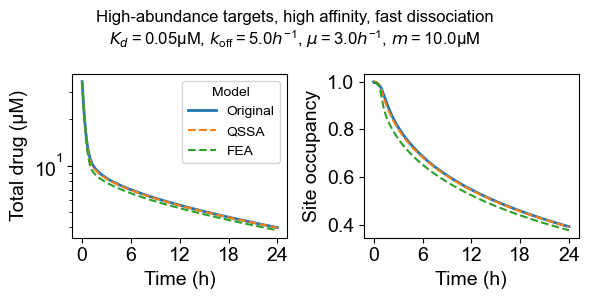

In [3]:
kd = 0.05
kon = 100
koff = kon * kd
mu = 3
m = 10
r = kd / m
c0 = 500 * kd
s0 = m * c0 / (kd + c0)

sol = solve_ivp(
    washout_zero_bound,
    t_span=[0, 24],
    y0=[s0 + c0, s0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_fea = solve_ivp(
    rebinding_two_phase_fea,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_qssa = solve_ivp(
    rebinding_two_phase_qssa,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu, 1e-4],
    max_step=0.01,
)
sol_qssa = solve_ivp(
    rebinding_qssa, t_span=[0, 24], y0=[s0], args=[kd, koff, m, mu], max_step=0.01
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(sol.t, sol.y[0], lw=2, label="Original")
ax[0].plot(sol_two_phase_qssa.t, sol_two_phase_qssa.y[0], ls="--", label="QSSA")
ax[0].plot(sol_two_phase_fea.t, sol_two_phase_fea.y[0], ls="--", label="FEA")
ax[0].set_yscale("log")
ax[1].plot(sol.t, sol.y[1] / m, lw=2)
ax[1].plot(
    sol_two_phase_qssa.t,
    [
        c_to_s_qssa(sol_two_phase_qssa.y[0][i], kon, koff, m, mu) / m
        for i in range(len(sol_two_phase_qssa.t))
    ],
    ls="--",
)
ax[1].plot(sol_two_phase_fea.t, c_to_s_fea(sol_two_phase_fea.y[0], r) / m, ls="--")
ax[0].set_ylabel("Total drug (μM)")
ax[1].set_ylabel("Site occupancy")
ax[0].legend(title="Model")
for bx in ax:
    bx.set_xlabel("Time (h)")
    bx.set_xticks(range(0, 30, 6))
fig.suptitle(
    "High-abundance targets, high affinity, fast dissociation\n"
    + f"$K_d = {kd}$μM, "
    + r"$k_{\mathrm{off}}=$"
    + f"${koff}h^{{-1}}$, "
    + r"$\mu=$"
    + f"${float(mu)}h^{{-1}}$, "
    + f"$m={float(m)}$μM"
)
save_fig("figSupp1-1", fmt="png", dpi=300)

# Fast washout

Saving figure figSupp1-2


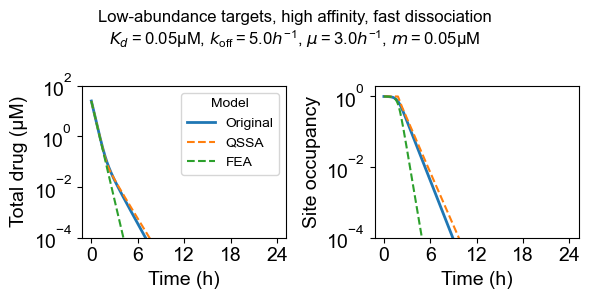

In [5]:
kd = 0.05
kon = 100
koff = kon * kd
mu = 3
m = 0.05
r = kd / m
c0 = 500 * kd
s0 = m * c0 / (kd + c0)

sol = solve_ivp(
    washout_zero_bound,
    t_span=[0, 24],
    y0=[s0 + c0, s0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_fea = solve_ivp(
    rebinding_two_phase_fea,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_qssa = solve_ivp(
    rebinding_two_phase_qssa,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu, 1e-2],
    max_step=0.01,
)
sol_qssa = solve_ivp(
    rebinding_qssa, t_span=[0, 24], y0=[s0], args=[kd, koff, m, mu], max_step=0.01
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(sol.t, sol.y[0], lw=2, label="Original")
ax[0].plot(sol_two_phase_qssa.t, sol_two_phase_qssa.y[0], ls="--", label="QSSA")
ax[0].plot(sol_two_phase_fea.t, sol_two_phase_fea.y[0], ls="--", label="FEA")
ax[0].set_yscale("log")
ax[1].plot(sol.t, sol.y[1] / m, lw=2)
ax[1].plot(
    sol_two_phase_qssa.t,
    c_to_s_qssa_vec(sol_two_phase_qssa.y[0], kon, koff, m, mu) / m,
    ls="--",
)
ax[1].plot(sol_two_phase_fea.t, c_to_s_fea(sol_two_phase_fea.y[0], r) / m, ls="--")
ax[0].set_ylabel("Total drug (μM)")
ax[1].set_ylabel("Site occupancy")
ax[0].legend(title="Model")
ax[0].set_ylim([1e-4, 1e2])
ax[1].set_ylim([1e-4, 2])
for bx in ax:
    bx.set_xlabel("Time (h)")
    bx.set_xticks(range(0, 30, 6))
    bx.set_yscale("log")
fig.suptitle(
    "Low-abundance targets, high affinity, fast dissociation\n"
    + f"$K_d = {kd}$μM, "
    + r"$k_{\mathrm{off}}=$"
    + f"${koff}h^{{-1}}$, "
    + r"$\mu=$"
    + f"${float(mu)}h^{{-1}}$, "
    + f"$m={float(m)}$μM"
)
save_fig("figSupp1-2", fmt="png", dpi=300)

# Slow dissociation

Saving figure figSupp1-3


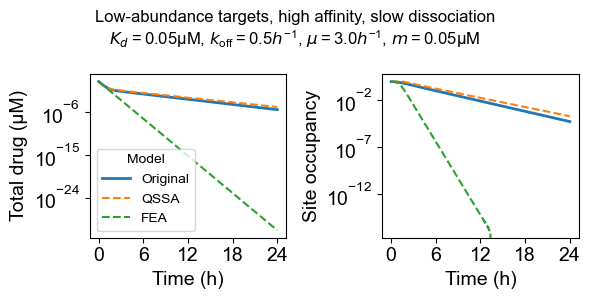

In [6]:
kd = 0.05
kon = 10
koff = kon * kd
mu = 3
m = 0.05
r = kd / m

c0 = 50 * kd
s0 = m * c0 / (kd + c0)

sol = solve_ivp(
    washout_zero_bound,
    t_span=[0, 24],
    y0=[s0 + c0, s0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_fea = solve_ivp(
    rebinding_two_phase_fea,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_qssa = solve_ivp(
    rebinding_two_phase_qssa,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu, 1e-4],
    max_step=0.01,
)
sol_qssa = solve_ivp(
    rebinding_qssa, t_span=[0, 24], y0=[s0], args=[kd, koff, m, mu], max_step=0.01
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(sol.t, sol.y[0], lw=2, label="Original")
ax[0].plot(sol_two_phase_qssa.t, sol_two_phase_qssa.y[0], ls="--", label="QSSA")
ax[0].plot(sol_two_phase_fea.t, sol_two_phase_fea.y[0], ls="--", label="FEA")
ax[0].set_yscale("log")
ax[1].plot(sol.t, sol.y[1] / m, lw=2)
ax[1].plot(
    sol_two_phase_qssa.t,
    c_to_s_qssa_vec(sol_two_phase_qssa.y[0], kon, koff, m, mu) / m,
    ls="--",
)
ax[1].plot(sol_two_phase_fea.t, c_to_s_fea(sol_two_phase_fea.y[0], r) / m, ls="--")
ax[0].set_ylabel("Total drug (μM)")
ax[1].set_ylabel("Site occupancy")
ax[0].legend(title="Model")
# ax[0].set_ylim([1e-4, 1e2])
# ax[1].set_ylim([1e-4, 1])
for bx in ax:
    bx.set_xlabel("Time (h)")
    bx.set_xticks(range(0, 30, 6))
    bx.set_yscale("log")
fig.suptitle(
    "Low-abundance targets, high affinity, slow dissociation\n"
    + f"$K_d = {kd}$μM, "
    + r"$k_{\mathrm{off}}=$"
    + f"${koff}h^{{-1}}$, "
    + r"$\mu=$"
    + f"${float(mu)}h^{{-1}}$, "
    + f"$m={float(m)}$μM"
)
save_fig("figSupp1-3", fmt="png", dpi=300)

# Low affinity

In [7]:
kd = 10
kon = 10
koff = kon * kd
mu = 3
m = 10
r = kd / m

Saving figure figSupp1-4


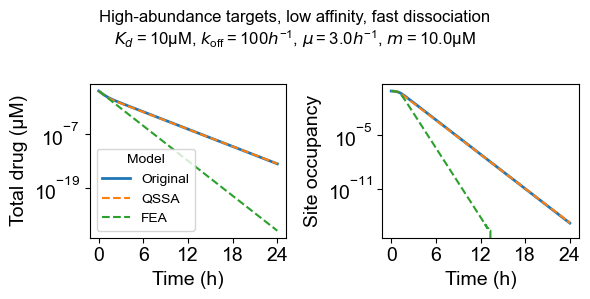

In [8]:
c0 = 50 * kd
s0 = m * c0 / (kd + c0)

sol = solve_ivp(
    washout_zero_bound,
    t_span=[0, 24],
    y0=[s0 + c0, s0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_fea = solve_ivp(
    rebinding_two_phase_fea,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_qssa = solve_ivp(
    rebinding_two_phase_qssa,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu, 1e-4],
    max_step=0.01,
)
sol_qssa = solve_ivp(
    rebinding_qssa, t_span=[0, 24], y0=[s0], args=[kd, koff, m, mu], max_step=0.01
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(sol.t, sol.y[0], lw=2, label="Original")
ax[0].plot(sol_two_phase_qssa.t, sol_two_phase_qssa.y[0], ls="--", label="QSSA")
ax[0].plot(sol_two_phase_fea.t, sol_two_phase_fea.y[0], ls="--", label="FEA")
ax[0].set_yscale("log")
ax[1].plot(sol.t, sol.y[1] / m, lw=2)
ax[1].plot(
    sol_two_phase_qssa.t,
    [
        c_to_s_qssa(sol_two_phase_qssa.y[0][i], kon, koff, m, mu) / m
        for i in range(len(sol_two_phase_qssa.t))
    ],
    ls="--",
)
ax[1].plot(sol_two_phase_fea.t, c_to_s_fea(sol_two_phase_fea.y[0], r) / m, ls="--")
ax[0].set_ylabel("Total drug (μM)")
ax[1].set_ylabel("Site occupancy")
ax[0].legend(title="Model")
# ax[0].set_ylim([1e-4, 1e2])
# ax[1].set_ylim([1e-4, 1])
for bx in ax:
    bx.set_xlabel("Time (h)")
    bx.set_xticks(range(0, 30, 6))
    bx.set_yscale("log")
fig.suptitle(
    "High-abundance targets, low affinity, fast dissociation\n"
    + f"$K_d = {kd}$μM, "
    + r"$k_{\mathrm{off}}=$"
    + f"${koff}h^{{-1}}$, "
    + r"$\mu=$"
    + f"${float(mu)}h^{{-1}}$, "
    + f"$m={float(m)}$μM"
)
save_fig("figSupp1-4", fmt="png", dpi=300)

# Fast diffusion

In [9]:
kd = 0.05
kon = 10
koff = kon * kd
mu = 3
m = 0.05
r = kd / m

Saving figure figSupp1-4


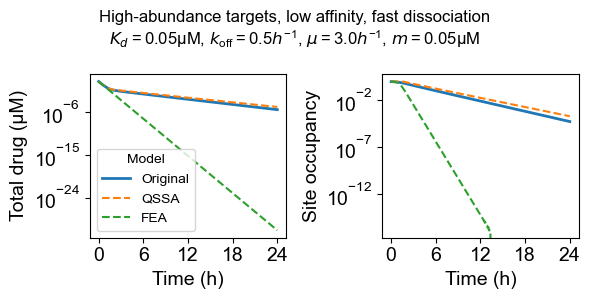

In [10]:
c0 = 50 * kd
s0 = m * c0 / (kd + c0)

sol = solve_ivp(
    washout_zero_bound,
    t_span=[0, 24],
    y0=[s0 + c0, s0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_fea = solve_ivp(
    rebinding_two_phase_fea,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu],
    max_step=0.01,
)
sol_two_phase_qssa = solve_ivp(
    rebinding_two_phase_qssa,
    t_span=[0, 24],
    y0=[s0 + c0],
    args=[kon, koff, m, mu, 1e-4],
    max_step=0.01,
)
sol_qssa = solve_ivp(
    rebinding_qssa, t_span=[0, 24], y0=[s0], args=[kd, koff, m, mu], max_step=0.01
)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].plot(sol.t, sol.y[0], lw=2, label="Original")
ax[0].plot(sol_two_phase_qssa.t, sol_two_phase_qssa.y[0], ls="--", label="QSSA")
ax[0].plot(sol_two_phase_fea.t, sol_two_phase_fea.y[0], ls="--", label="FEA")
ax[0].set_yscale("log")
ax[1].plot(sol.t, sol.y[1] / m, lw=2)
ax[1].plot(
    sol_two_phase_qssa.t,
    [
        c_to_s_qssa(sol_two_phase_qssa.y[0][i], kon, koff, m, mu) / m
        for i in range(len(sol_two_phase_qssa.t))
    ],
    ls="--",
)
ax[1].plot(sol_two_phase_fea.t, c_to_s_fea(sol_two_phase_fea.y[0], r) / m, ls="--")
ax[0].set_ylabel("Total drug (μM)")
ax[1].set_ylabel("Site occupancy")
ax[0].legend(title="Model")
# ax[0].set_ylim([1e-4, 1e2])
# ax[1].set_ylim([1e-4, 1])
for bx in ax:
    bx.set_xlabel("Time (h)")
    bx.set_xticks(range(0, 30, 6))
    bx.set_yscale("log")
fig.suptitle(
    "High-abundance targets, low affinity, fast dissociation\n"
    + f"$K_d = {kd}$μM, "
    + r"$k_{\mathrm{off}}=$"
    + f"${koff}h^{{-1}}$, "
    + r"$\mu=$"
    + f"${float(mu)}h^{{-1}}$, "
    + f"$m={float(m)}$μM"
)
save_fig("figSupp1-4", fmt="png", dpi=300)